# Solving the Spherical Poisson Equation

This notebook demonstrates the solver for the spherical Poisson equation
$$\Delta u=f$$
on the **half-line** domain $\Omega = (0,\infty) \times S^2$ for a given **source $f$**.
In spherical coordinates $(r, \theta, \varphi)$ the Laplacian splits into a radial and an angular part

$$\Delta u = \frac{1}{r^2} \frac{\partial}{\partial r}\left( r^2 \frac{\partial}{\partial r} u \right) + \frac{1}{r^2}\,\Delta_{S^2} u$$

where $\Delta_{S^2}$ is the Laplace-Beltrami operator on the unit sphere.
We use spherical harmonics to diagonalize the angular part since those are the eigenfunctions of the Laplace-Beltrami operator
$$\Delta_{S^2} Y_\ell^m = -\ell(\ell+1)\, Y_\ell^m$$
The Spherical Harmonic Transformation 
$$
u(r,\theta,\varphi)=\sum_{\ell,m}u_{\ell m}(r)Y_\ell^m(\theta,\varphi),
\qquad
f(r,\theta,\varphi)=\sum_{\ell,m}f_{\ell m}(r)Y_\ell^m(\theta,\varphi).
$$
then gives us one ODE per degree $\ell$ 
$$u_\ell'' + \frac{2}{r}\, u_\ell' - \frac{\ell(\ell+1)}{r^2} u_\ell = f_\ell.$$
We also assume that $u \rightarrow 0$ at infinity and we have regularity at the center.

In the following we will start by only solving the radial part and continue with the full sperhical problem.

## 1 Solving the Radial Poisson for $\ell=0$
First we want to tackle an easier case for degree $\ell=0$ which describes the monopole (constant along angular direction). This reduces our problem to solve the ODE $(r^2 u'(r))' = r^2 f(r)$ which has the analytical solution
$$u(r)=-\int_ 0^\infty \frac{s^2}{max(r,s)} f(s)ds.$$

But first we need to define our discrete grid and the source term.

### 1.1 Setup

In [233]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch_harmonics.examples import RadialPoissonSolver
from torch_harmonics.quadrature import precompute_radii

### 1.2 Radial Grid
We consider a geometric radial grid $r_k = r_0 q^k$ with $k = 0, . . . , Nr − 1$, so it is uniform in $x = \log r$. This leads to more grid points near the origin and only a sparse field near the outer boundary. The plot below compares both coordinate types.

In [234]:
NR, RMIN, RMAX = 1024, 1e-3, 1e3
DOMAIN = "half-line"

x, r, w = precompute_radii(NR, RMIN, RMAX, domain=DOMAIN)

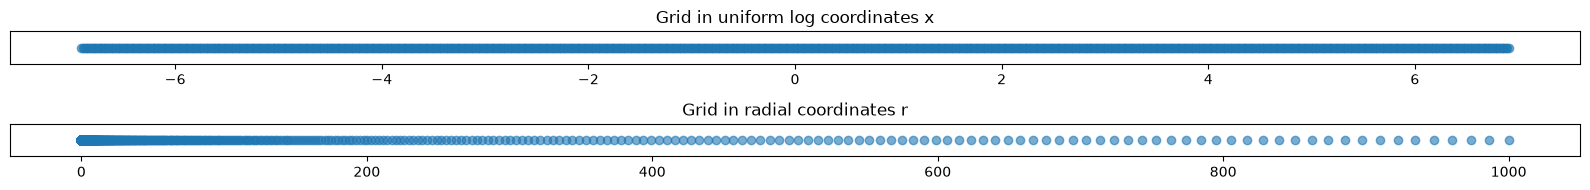

In [235]:
def plot_radial_grid(r, x, rname="r"):
    fig, ax = plt.subplots(2, 1, figsize=(16, 2))
    ax[0].scatter(x, np.zeros_like(x), alpha=0.6)
    ax[1].scatter(r, np.zeros_like(r), alpha=0.6)

    ax[0].set_yticks([])
    ax[1].set_yticks([])

    ax[0].set_title("Grid in uniform log coordinates x")
    ax[1].set_title(f"Grid in radial coordinates {rname}")

    fig.tight_layout()
    plt.show()

plot_radial_grid(r, x)

### 1.3 A simple source term: A uniform Ball
This source is simple enough to solve by hand. For that purpose we use a uniform ball since it is constant on the sphere and therefore $\ell=0$.
Here we have a constant inside a ball of radius $a$ and zero outside of the ball $$f_{ball}(r) = \begin{cases} c, & r \le a \\ 0, & r > a \end{cases}$$


In [236]:
r_ball = 1.0
c_ball = 1.0

def ball(r, a=r_ball, c=c_ball):
    """Ball with radius `a` and constant value `c`."""
    out = torch.zeros_like(r)
    inside = r <= a
    out[inside] = c
    return out

f_ball = ball(r)

Inserting $f_{ball}$ into the analytical solution leads to
$$u(r) = \begin{cases} c\left(\dfrac{r^2}{6} - \dfrac{a^2}{2}\right), & r \le a \\[2ex] -\dfrac{c a^3}{3r}, & r > a \end{cases}$$

In [237]:
u_ball = torch.zeros_like(r)
inside = r <= r_ball
outside = r > r_ball

u_ball[inside] = c_ball * (r[inside] ** 2 - 3 * r_ball**2) / 6.0
u_ball[outside] = -c_ball * r_ball**3 / (3 * r[outside])

Let's visualize source and solution

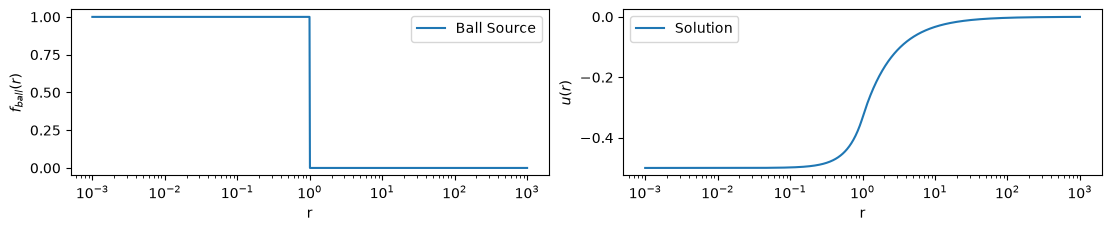

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(11, 2.2), layout="constrained")
axes[0].semilogx(r, f_ball, label="Ball Source")
axes[0].set_xlabel("r"); axes[0].set_ylabel(r"$f_{ball}(r)$"); axes[0].legend()

axes[1].semilogx(r, u_ball, label="Solution")
axes[1].set_xlabel("r"); axes[1].set_ylabel(r"$u(r)$"); axes[1].legend()
plt.show()

## 2 Solving the full spherical Poisson equation via Green's Operator

Next we want to solve the full spherical Poisson on the half-line $(0,\infty)\times S^2$ and set up a `RadialPoissonSolver` using the Green's Operator [1]
$$u_{\ell m}(r) = -\frac{1}{2\ell+1}\int r_<^{\ell} r_>^{-(\ell+1)} f_{\ell m}(s) s^2 ds$$

where $r_< = \min(r,s)$, $r_> = \max(r,s)$. This gives the exact solution in one step and is discretized via quadrature to one matrix-vector product per degree $\ell$. Note that the Green's Operator reduces to our previous solution for $\ell = 0$.

[1] J. D. Jackson, *Classical Electrodynamics*, 3rd ed., Wiley, 1999, Sec. 3.9

In [239]:
NLAT, NLON = 64, 128
GRID = "legendre-gauss"

solver = RadialPoissonSolver(NLAT, NLON, NR, RMIN, RMAX, grid=GRID, domain=DOMAIN)

### 2.1 The Ball as a test case in 3D
Before we move on, let's test the previous simple ball source term again, but now via our full 3D Green's solver. The solver has function `solver.ball_source(..)` to get the same source term from 1.3 extended to $S^2$ and we get the solution $u$ via `solver.solve(..)`.

In [240]:
f_ball_3d = solver.ball_source(radius=r_ball, value=c_ball)
u_ball_3d = solver.solve(f_ball_3d)

Let's visualize the ball source term and the solution for radius and latitude:

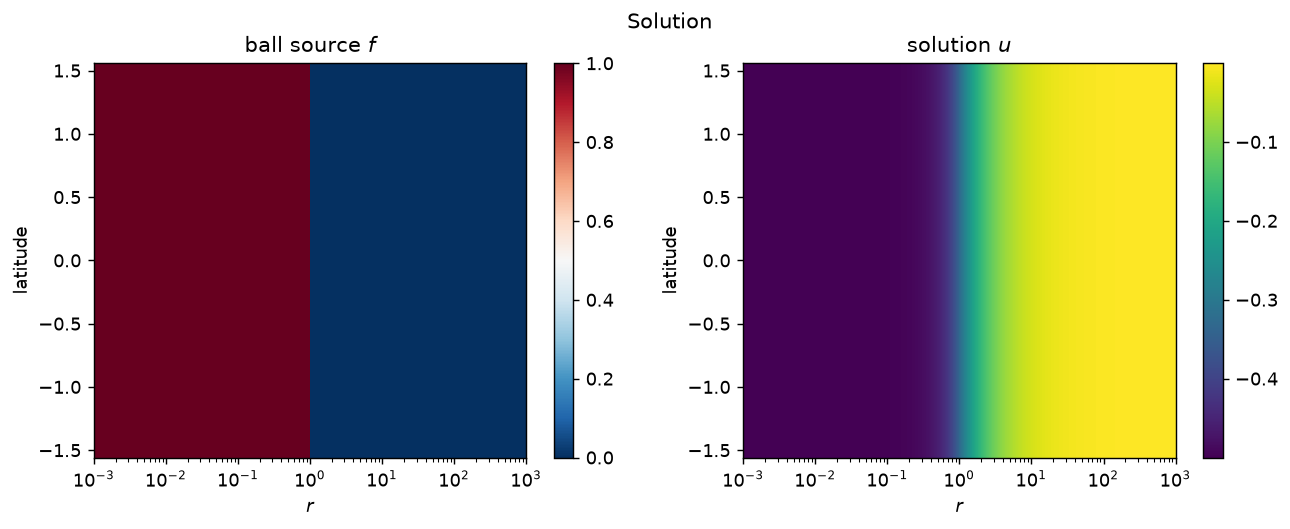

In [241]:
# plot solution
fig = plt.figure(figsize=(12, 4), dpi=128)
ax1, ax2 = fig.subplots(1, 2, width_ratios=[1, 1])

solver.plot_meridional(f_ball_3d, ax=ax1, title=r"ball source $f$", projection="log", cmap="RdBu_r")
solver.plot_meridional(u_ball_3d, ax=ax2, title=r"solution $u$", projection="log")

fig.suptitle("Solution")
plt.show()

We can also check wether our analytical solution from above matches the 3D solver

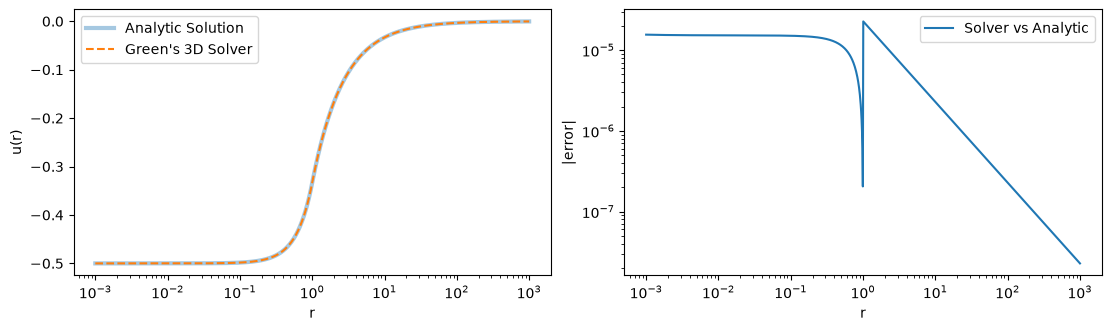

In [242]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), layout="constrained")
axes[0].semilogx(r, u_ball, lw=3, alpha=0.4, label="Analytic Solution")
axes[0].semilogx(r, u_ball_3d[:, 0, 0], "--", label="Green's 3D Solver")
axes[0].set_xlabel("r"); axes[0].set_ylabel("u(r)"); axes[0].legend()
axes[1].loglog(r, (u_ball_3d[:, 0, 0] - u_ball).abs(), label="Solver vs Analytic")
axes[1].set_xlabel("r"); axes[1].set_ylabel("|error|"); axes[1].legend()
plt.show()

We can see that both solutions match up nicely!

### 2.2 Random Bumps as a Source Term
Next we will look into more interesting source terms that are not constant on $S^2$ like the previous ball source. The solver additionally provides the source `solver.random_bump_source(..)` which consists of multiple blobs. Each blob is a random angular field of degrees $\ell \le$ `l_src` on $S^2$, enveloped by a compact radial bump of random width. An `nblobs` number of blobs at random radii are summed to build the full forcing field.

The plots below show a forcing example as a meridional slice (lat and r) and the $S^2$ slice at a selected radius `k` which is also marked as a dashed line in the other two plots.

In [243]:
f = solver.random_bump_source(nblobs=8, l_src=4, margin=0.12, width=(0.03, 0.1))

Let's visualize the new source:

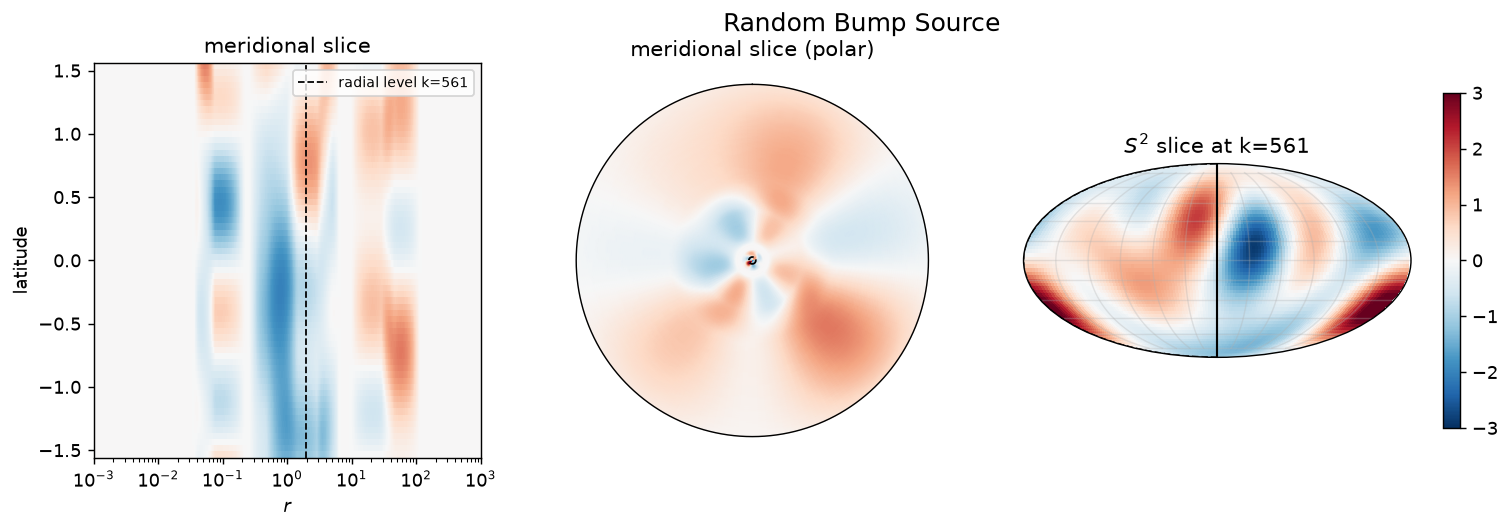

In [244]:
# plot of forcing function
k = f.abs().amax(dim=(-1, -2)).argmax().item()
ilon = solver.nlon // 2          # maps to mollweide x = 0, the visible centre
kw = dict(vmin=-3, vmax=3, colorbar=False, cmap="RdBu_r")

fig = plt.figure(figsize=(16, 4), dpi=128)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2], projection="mollweide")

solver.plot_meridional(f, ax=ax1, ilon=ilon, title="meridional slice", projection="log", **kw)
ax1.axvline(solver.r[k].cpu(), c='k', ls='--', lw=1)
ax1.legend(["radial level k=" + str(k)], loc="upper right", fontsize=8)

solver.plot_meridional(f, ax=ax2, ilon=ilon, title="meridional slice (polar)", projection="polar", rmax=100, **kw)
ax2.add_patch(plt.Circle((0, 0), solver.r[k].item(), fill=False, ec='k', ls='--', lw=1))

im = solver.plot_sphere(f[k], ax=ax3, title=r"$S^2$ slice at k=" + str(k), **kw)
x0 = solver.lons[ilon].item() - np.pi
ax3.vlines(x0, -np.pi/2, np.pi/2, colors='k', ls='-', lw=1.2)
ax3.vlines(np.remainder(x0 + 2*np.pi, 2*np.pi) - np.pi, -np.pi/2, np.pi/2, colors='k', ls='--', lw=1)

fig.suptitle("Random Bump Source", fontsize=14)
fig.colorbar(im, ax=[ax1, ax2, ax3], shrink=0.85, pad=0.02)
plt.show()


As before, we can easily get the solution with our Green's Operator based solver:

In [245]:
u = solver.solve(f)

which leads us to this solution:

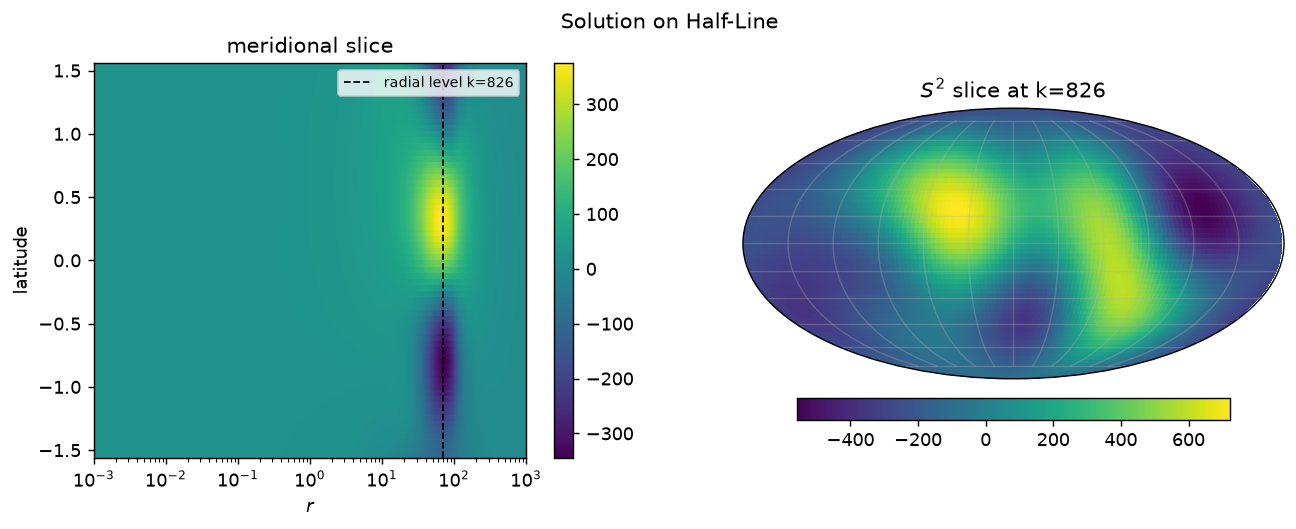

In [246]:
# plot solution
k = u.abs().amax(dim=(-1, -2)).argmax().item()

fig = plt.figure(figsize=(12, 4), dpi=128)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], projection="mollweide")

solver.plot_meridional(u, ax=ax1, ilon=ilon, title="meridional slice", projection="log")
ax1.axvline(solver.r[k].cpu(), c='k', ls='--', lw=1)
ax1.legend(["radial level k=" + str(k)], loc="upper right", fontsize=8)

im = solver.plot_sphere(u[k], ax=ax2, title=r"$S^2$ slice at k=" + str(k))

fig.suptitle("Solution on Half-Line")
plt.show()

## 3 Poisson Dataset
To train an Operator or any other network on the Poisson Equation, we can use the class `PoissonDataset`.

In [247]:
from torch_harmonics.examples import PoissonDataset

ds = PoissonDataset(num_examples=512, normalize=True)

inp, tar = ds[0]
print(f"input: {tuple(inp.shape)}, target: {tuple(tar.shape)}")

input: (256, 64, 128), target: (256, 64, 128)
